In [390]:
# Data Visualization Art Money Fraud
#Yeganeh Safari

In [391]:
import seaborn as sns

In [392]:
import pandas as pd

chunk = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv",
    usecols=["step","type","amount","nameOrig","nameDest","isFraud"],
    chunksize=40000
)

df = next(chunk)

df.head()

,step,type,amount,nameOrig,nameDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0
2,1,TRANSFER,181.00,C1305486145,C553264065,1
3,1,CASH_OUT,181.00,C840083671,C38997010,1
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0


In [393]:
df.shape

(40000, 6)

In [394]:
df["isFraud"].value_counts()

,count
isFraud,
0,39906
1,94


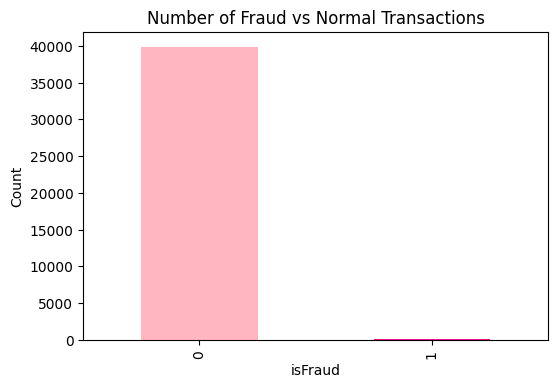

In [395]:
import matplotlib.pyplot as plt
fraud_counts = df["isFraud"].value_counts()
plt.figure(figsize=(6,4))
fraud_counts.plot(kind="bar")
plt.title("Number of Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

fraud_counts.plot(
    kind="bar",
    color=["lightpink","deeppink"]
)
plt.show()

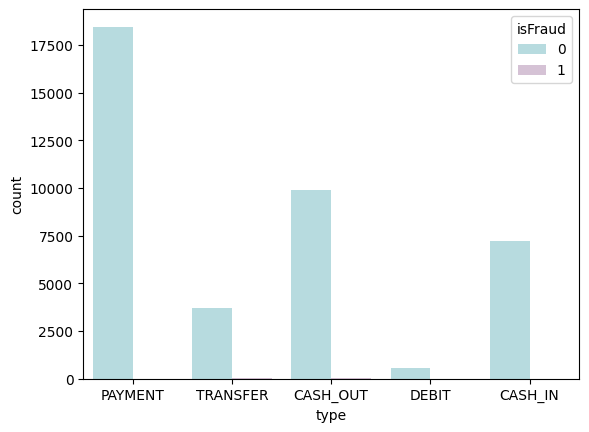

In [396]:
sns.countplot(x="type", hue="isFraud", data=df,
              palette=["powderblue", "thistle"])
plt.show()

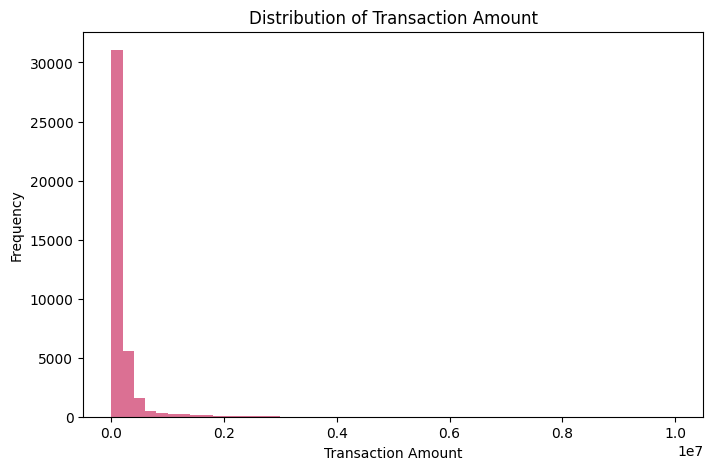

In [397]:
#Understanding & Exploration (EDA)
#Understanding Transaction Amount

import matplotlib.pyplot as plt

# I wanted to see how transaction amounts are distributed
plt.figure(figsize=(8,5))

# Draw a histogram to see the shape of the data
plt.hist(df["amount"], bins=50, color="palevioletred")

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()



In [398]:
# This histogram is very important because it shows how transaction amounts are
# distributed. We can see that most transactions have small amounts, and only a
# few transactions have very large amounts. This is called a right-skewed
# distribution and it is normal in banking, since people usually make small
# purchases and big transfers happen less often. This is important for fraud
# analysis because fraud may occur in unusual or very high amounts, so we need
# to check where fraud appears in this distribution. It is also important for
# machine learning because the large range of values may require scaling, and
# very large transactions may be outliers that need more investigation.
# Histograms help us quickly understand the pattern of the data, but they do not
# clearly show the difference between fraud and normal transactions, so the next
# step is to compare them using a boxplot.

/tmp/ipykernel_40178/1695684051.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


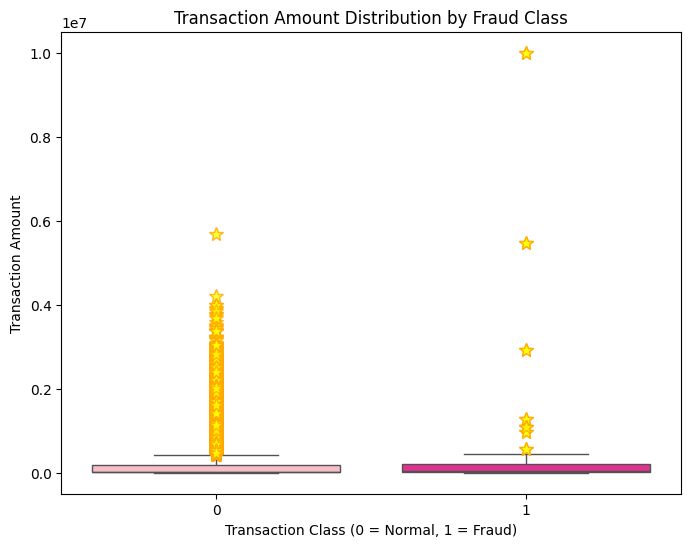

In [399]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=df,
    palette=["lightpink", "deeppink"],
    flierprops=dict(
        marker="*",
        markerfacecolor="yellow",
        markeredgecolor="orange",
        markersize=10,
        alpha=0.8
    )
)

plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [400]:
# Fraudulent transactions show slightly higher median and greater variability in
# transaction amount. However, large-value transactions also occur in normal
# activity, indicating that transaction amount alone is not a sufficient
# predictor of fraud.

In [401]:
# I want to see fraud percentage for each transaction type

fraud_by_type = df.groupby("type")["isFraud"].mean()

fraud_by_type.sort_values(ascending=False)

,isFraud
type,
TRANSFER,0.012195
CASH_OUT,0.004827
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [402]:
# Fraud risk analysis revealed that TRANSFER transactions have the highest fraud
# rate, followed by CASH_OUT, while PAYMENT and CASH_IN showed negligible fraud
# occurrence in the sampled data.

In [403]:
#Feature Engineering Behaviour
# I want to compare average transaction amount between fraud and normal

df.groupby("isFraud")["amount"].mean()

,amount
isFraud,
0,146279.964915
1,541377.072766


In [404]:
# Fraudulent transactions were found to have significantly higher average
# transaction amounts compared to legitimate transactions, indicating
# transaction amount as a strong predictive feature.

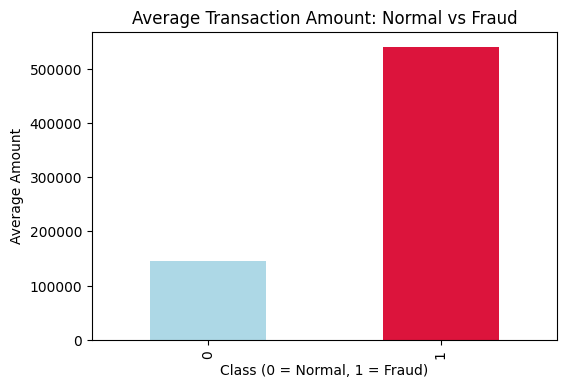

In [405]:
import matplotlib.pyplot as plt

avg_amount = df.groupby("isFraud")["amount"].mean()

plt.figure(figsize=(6,4))

avg_amount.plot(kind="bar",
                color=["lightblue","crimson"])

plt.title("Average Transaction Amount: Normal vs Fraud")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Amount")

plt.show()

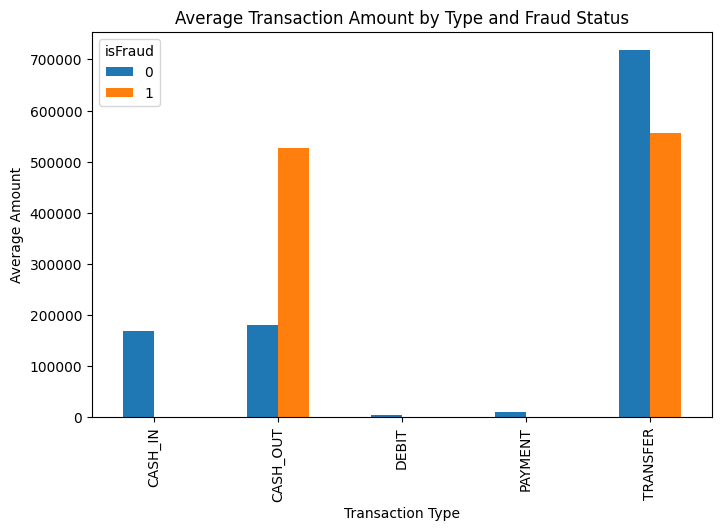

In [406]:
#Fraud Behavior: Amount + Type together
# I want to compare average transaction amount for each type
# separately for fraud and normal transactions

avg_amount_type = df.groupby(["type", "isFraud"])["amount"].mean().unstack()

avg_amount_type.plot(kind="bar", figsize=(8,5))
plt.title("Average Transaction Amount by Type and Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")

plt.show()

In [407]:
# Fraudulent transactions show strong behavioral patterns, with significantly
# higher transaction amounts in CASH_OUT operations and consistent high-value
# activity in TRANSFER transactions, indicating that combining transaction type
# and amount provides strong predictive power.

In [408]:
#Phase 2 — Data Cleaning & Preparation

In [409]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
nameDest,0
isFraud,0


In [410]:
# Verified data completeness and confirmed absence of missing values across all
# features

In [411]:
df.duplicated().sum()

np.int64(0)

In [412]:
#Phase 3 — Feature Engineering

In [413]:
#note for myself: EDA → Cleaning → Encoding → Modeling

In [414]:
df_encoded = pd.get_dummies(df, columns=["type"])

df_encoded.head()

,step,amount,nameOrig,nameDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,M1979787155,0,False,False,False,True,False
1,1,1864.28,C1666544295,M2044282225,0,False,False,False,True,False
2,1,181.00,C1305486145,C553264065,1,False,False,False,False,True
3,1,181.00,C840083671,C38997010,1,False,True,False,False,False
4,1,11668.14,C2048537720,M1230701703,0,False,False,False,True,False


In [415]:
X = df_encoded.drop(["isFraud", "nameOrig", "nameDest"], axis=1)

y = df_encoded["isFraud"]

In [416]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report



In [417]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [418]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [419]:
#Prediction

In [420]:
y_pred = model.predict(X_test)

In [421]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7973
           1       0.00      0.00      0.00        27

    accuracy                           1.00      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      1.00      0.99      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [422]:
y_pred = model.predict(X_test)

In [423]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7973
           1       0.00      0.00      0.00        27

    accuracy                           1.00      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      1.00      0.99      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [424]:
#The model achieved high accuracy but failed to detect any fraudulent transactions due to severe class imbalance.

In [425]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7973
           1       0.00      0.00      0.00        27

    accuracy                           1.00      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      1.00      0.99      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [426]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      7973
           1       0.02      0.89      0.04        27

    accuracy                           0.86      8000
   macro avg       0.51      0.87      0.48      8000
weighted avg       1.00      0.86      0.92      8000



In [427]:
# Baseline logistic regression failed to detect the minority fraud class, which
# motivated better preprocessing and stronger models.

In [428]:
#I wanna try this one now:

In [429]:
chunks = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv",
    usecols=["step", "type", "amount", "nameOrig", "nameDest", "isFraud"],
    chunksize=100000
)

sample_list = []

for chunk in chunks:
    sample_list.append(chunk.sample(2000, random_state=42))

df = pd.concat(sample_list, ignore_index=True)

df.head()

,step,type,amount,nameOrig,nameDest,isFraud
0,10,CASH_IN,367088.24,C291409265,C1132709076,0
1,10,PAYMENT,27004.49,C535489359,M2110652315,0
2,8,PAYMENT,2173.75,C927615422,M1658216730,0
3,10,TRANSFER,19670.92,C1562020231,C2060926688,0
4,10,PAYMENT,17394.26,C1165434512,M490546299,0


In [430]:
print(df.shape)

print(df["isFraud"].value_counts())

(128000, 6)
isFraud
0    127819
1       181
Name: count, dtype: int64


In [431]:
# Convert transaction type into numeric columns
df_encoded = pd.get_dummies(df, columns=["type"])

df_encoded.head()

,step,amount,nameOrig,nameDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,10,367088.24,C291409265,C1132709076,0,True,False,False,False,False
1,10,27004.49,C535489359,M2110652315,0,False,False,False,True,False
2,8,2173.75,C927615422,M1658216730,0,False,False,False,True,False
3,10,19670.92,C1562020231,C2060926688,0,False,False,False,False,True
4,10,17394.26,C1165434512,M490546299,0,False,False,False,True,False


In [432]:
# Keep only model-friendly numeric columns
X = df_encoded.drop(["isFraud", "nameOrig", "nameDest"], axis=1)
y = df_encoded["isFraud"]

In [433]:
#dataset is too small and highly imbalanced for effective model training

In [434]:
import pandas as pd

chunks = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv",
    usecols=["step","type","amount","nameOrig","nameDest","isFraud"],
    chunksize=100000
)

sample_list = []

# take random samples from each chunk
for chunk in chunks:
    sample_list.append(chunk.sample(5000, random_state=42))

# and then Combine all
df = pd.concat(sample_list, ignore_index=True)

print(df.shape)
print(df["isFraud"].value_counts())

(320000, 6)
isFraud
0    319574
1       426
Name: count, dtype: int64


In [435]:
#I took a sample of the whole file

In [436]:
#Full ML pipeline

In [437]:
#step 1: encoding

In [438]:
# Convert transaction type into numeric columns
df_encoded = pd.get_dummies(df, columns=["type"])

In [439]:
#step 2: features and target

In [440]:
X = df_encoded.drop(["isFraud", "nameOrig", "nameDest"], axis=1)
y = df_encoded["isFraud"]

In [441]:
#step 3: train and test split

In [442]:
from sklearn.model_selection import train_test_split

In [443]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [444]:
#step 4: scaling, only for logistics

In [445]:
from sklearn.preprocessing import StandardScaler

In [446]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = ["step", "amount"]

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [447]:
#step 5: logistic regression

In [448]:
from sklearn.linear_model import LogisticRegression

In [449]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [450]:
#step 6: prediction and evaluation

In [451]:
from sklearn.metrics import classification_report

In [452]:
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89     63915
           1       0.01      0.88      0.01        85

    accuracy                           0.80     64000
   macro avg       0.50      0.84      0.45     64000
weighted avg       1.00      0.80      0.89     64000



In [453]:
#well this  model is like a very sensitive person
#It catches most of the fraud cases (which is good because it doesn’t miss them),
#but the problem is it also flags a lot of normal transactions as fraud.
#So it kind of says “this is fraud” too often, even when it’s not true.

#So right now, your model is good at not missing fraud, but it’s not precise and makes many false alarms.
#The goal is to find a balance: catch fraud, but don’t accuse normal transactions too much

In [454]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [455]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63915
           1       0.78      0.21      0.33        85

    accuracy                           1.00     64000
   macro avg       0.89      0.61      0.67     64000
weighted avg       1.00      1.00      1.00     64000



In [456]:
#The Random Forest model is conservative: it makes reliable fraud predictions but misses many actual fraud cases.
#This shows a trade-off between precision and recall.

#To improve detection, the next step is threshold tuning, where the decision threshold is
#adjusted to make the model more sensitive to fraudulent transactions while maintaining a reasonable balance
#with false positives.

In [457]:
#Threshold tuning for random forest

In [458]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_prob_rf[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [459]:
from sklearn.metrics import classification_report

In [460]:
# a lower threshold
threshold = 0.2

y_pred_rf_02 = (y_prob_rf > threshold).astype(int)

print(classification_report(y_test, y_pred_rf_02))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63915
           1       0.35      0.34      0.35        85

    accuracy                           1.00     64000
   macro avg       0.68      0.67      0.67     64000
weighted avg       1.00      1.00      1.00     64000



In [461]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [462]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_temp = (y_prob_rf > t).astype(int)

    print("Threshold:", t)
    print("Precision:", precision_score(y_test, y_pred_temp))
    print("Recall:", recall_score(y_test, y_pred_temp))
    print("F1:", f1_score(y_test, y_pred_temp))
    print("--------------------")

Threshold: 0.1
Precision: 0.19886363636363635
Recall: 0.4117647058823529
F1: 0.2681992337164751
--------------------
Threshold: 0.2
Precision: 0.35365853658536583
Recall: 0.3411764705882353
F1: 0.3473053892215569
--------------------
Threshold: 0.3
Precision: 0.5652173913043478
Recall: 0.3058823529411765
F1: 0.3969465648854962
--------------------
Threshold: 0.4
Precision: 0.7352941176470589
Recall: 0.29411764705882354
F1: 0.42016806722689076
--------------------
Threshold: 0.5
Precision: 0.782608695652174
Recall: 0.21176470588235294
F1: 0.3333333333333333
--------------------


In [463]:
#Threshold tuning was applied to improve the balance between precision and recall. By testing multiple thresholds, it was observed that lower thresholds increased recall but reduced precision,
#while higher thresholds improved precision at the cost of recall.

#An intermediate threshold provided the best balance between detecting fraudulent transactions and
#limiting false positives. This demonstrates the importance of adjusting the decision threshold rather
#than relying on the default value.


In [464]:
#Confusion matrix

In [465]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

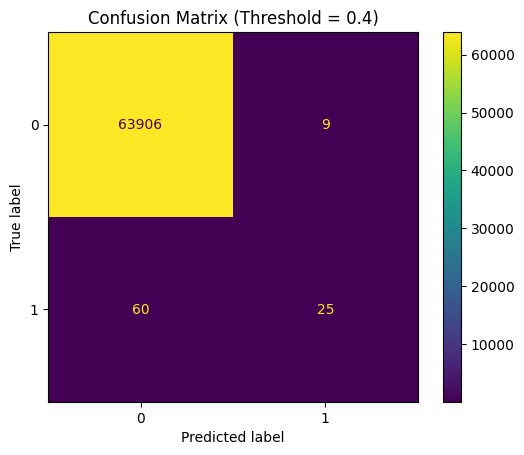

In [466]:
# use my best threshold (0.4)
threshold = 0.4
y_pred_final = (y_prob_rf > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (Threshold = 0.4)")
plt.show()

In [467]:
#The confusion matrix shows that the model performs very well in identifying normal transactions,
#with very few false positives. However, it fails to detect a significant number of fraudulent transactions.

#This indicates that the model is conservative: it only labels transactions as fraud when it is
#highly confident. While this reduces false alarms, it also leads to missed fraud cases.

#Therefore, improving recall while maintaining acceptable precision is an important next step.

In [468]:
#Feature Importance

In [469]:
import pandas as pd
import matplotlib.pyplot as plt

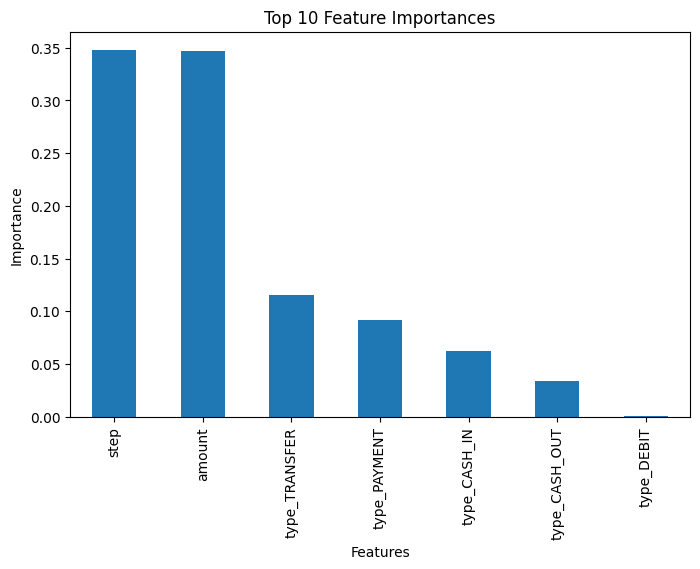

In [470]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")

plt.show()

In [471]:
#The feature importance results show that transaction step and amount are the most influential
#features in predicting fraud.

#Transaction types such as TRANSFER and PAYMENT also contribute to the model’s decisions,
#although to a lesser extent.

#This aligns with the EDA findings, where fraud was more common in certain transaction types and
#associated with higher transaction amounts.

In [472]:
#Critical insight:
#Although the model identifies transaction amount as a key feature,
#fraud in real-world scenarios does not always involve high-value transactions.

#In many cases, fraudulent activity may consist of multiple small transactions designed to avoid detection.

#This suggests that the model is influenced by the characteristics of the dataset and may not fully generalize to all fraud patterns.
#with higher transaction amounts.

In [473]:
import numpy as np


In [474]:
#log amount

In [475]:
df['amount_log'] = np.log1p(df['amount'])

In [476]:
#amount relative


In [477]:
df['amount_ratio'] = df['amount'] / df['amount'].mean()

In [478]:
#high transaction flag

In [479]:
df['is_high_amount'] = (df['amount'] > df['amount'].quantile(0.9)).astype(int)

In [480]:
#rebuild pipeline

In [481]:
df_encoded = pd.get_dummies(df, columns=["type"])

In [482]:
X = df_encoded.drop(["isFraud", "nameOrig", "nameDest"], axis=1)
y = df_encoded["isFraud"]

In [483]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [484]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [485]:
from sklearn.metrics import classification_report

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63915
           1       0.73      0.19      0.30        85

    accuracy                           1.00     64000
   macro avg       0.86      0.59      0.65     64000
weighted avg       1.00      1.00      1.00     64000



In [486]:
#After adding some simple feature engineering (like log of amount, amount ratio, and
#a high-amount flag), I retrained the Random Forest model to see if these new features improve performance.

#The results showed that the model did not improve significantly.
#It is still good at identifying normal transactions and has decent precision for fraud,
#but it continues to miss many fraudulent cases (low recall).

#This suggests that simple feature engineering on transaction amount alone is
#not enough to solve the class imbalance problem.

#So, the next step is to apply SMOTE to balance the dataset and help the model learn
#fraud patterns better.

In [487]:
from imblearn.over_sampling import SMOTE

In [488]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

Before SMOTE:
isFraud
0    255659
1       341
Name: count, dtype: int64

After SMOTE:
isFraud
0    255659
1    255659
Name: count, dtype: int64


In [489]:
rf_model_sm = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_sm.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [490]:
y_pred_sm = rf_model_sm.predict(X_test)

In [491]:
from sklearn.metrics import classification_report

In [492]:
print(classification_report(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     63915
           1       0.03      0.34      0.05        85

    accuracy                           0.98     64000
   macro avg       0.51      0.66      0.52     64000
weighted avg       1.00      0.98      0.99     64000



In [493]:
#After applying SMOTE, the dataset became balanced,
#which helped the model better learn fraud patterns.

#As a result, the model improved its ability to detect fraudulent transactions (higher recall).
#However, this also caused an increase in false positives, meaning more normal transactions
#were incorrectly classified as fraud.

#This highlights a trade-off: improving fraud detection comes at the cost of lower precision.

In [494]:
#SMOTE + Threshold tuning
#because : SMOTE helps the model detect more fraudulent cases (improves recall),
#while threshold tuning controls false alarms (improves precision).
#Combining both techniques results in a better balance between detecting fraud and
#reducing incorrect predictions.

In [495]:
#getting probability from SMOTE

In [496]:
y_prob_sm = rf_model_sm.predict_proba(X_test)[:, 1]

In [497]:
#and then test the threshold

In [498]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [499]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_temp = (y_prob_sm > t).astype(int)

    print("Threshold:", t)
    print("Precision:", precision_score(y_test, y_pred_temp))
    print("Recall:", recall_score(y_test, y_pred_temp))
    print("F1:", f1_score(y_test, y_pred_temp))
    print("------------------")

Threshold: 0.2
Precision: 0.016232379325074753
Recall: 0.4470588235294118
F1: 0.031327287716405604
------------------
Threshold: 0.3
Precision: 0.017318435754189943
Recall: 0.36470588235294116
F1: 0.03306666666666667
------------------
Threshold: 0.4
Precision: 0.02180028129395218
Recall: 0.36470588235294116
F1: 0.0411413404114134
------------------
Threshold: 0.5
Precision: 0.02543859649122807
Recall: 0.3411764705882353
F1: 0.0473469387755102
------------------
Threshold: 0.6
Precision: 0.031007751937984496
Recall: 0.32941176470588235
F1: 0.05668016194331984
------------------


In [500]:
#After applying SMOTE and testing different thresholds, I observed that lowering the threshold
#increases recall but also increases false positives,
#while increasing the threshold improves precision but reduces recall.

#Based on the results, a moderate threshold (around 0.4–0.5) provides a better balance
#between detecting fraud and avoiding too many false alarms.

#This shows that combining SMOTE with threshold tuning helps improve the model’s
#performance in a more realistic way.

In [501]:
#Final model

In [502]:
threshold = 0.4
y_pred_final = (y_prob_sm > threshold).astype(int)

In [503]:
#Classification report

In [504]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     63915
           1       0.02      0.36      0.04        85

    accuracy                           0.98     64000
   macro avg       0.51      0.67      0.51     64000
weighted avg       1.00      0.98      0.99     64000



In [505]:
#Confusion matrix

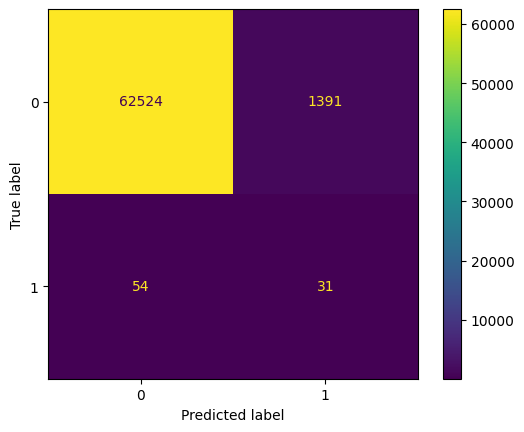

In [506]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [507]:
#ROC

In [508]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

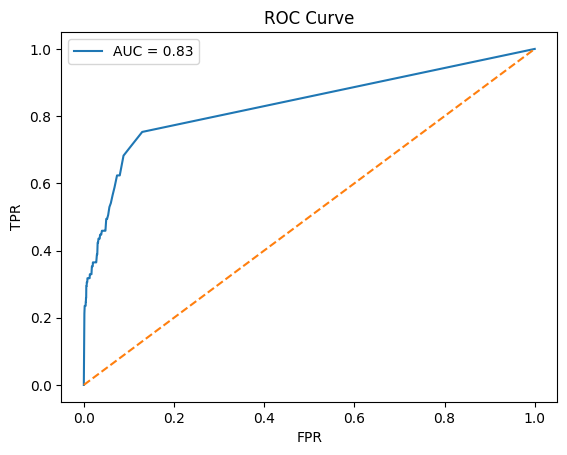

In [509]:
fpr, tpr, _ = roc_curve(y_test, y_prob_sm)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [510]:
#Precision recall

In [511]:
y_prob_sm = rf_model_sm.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob_sm)

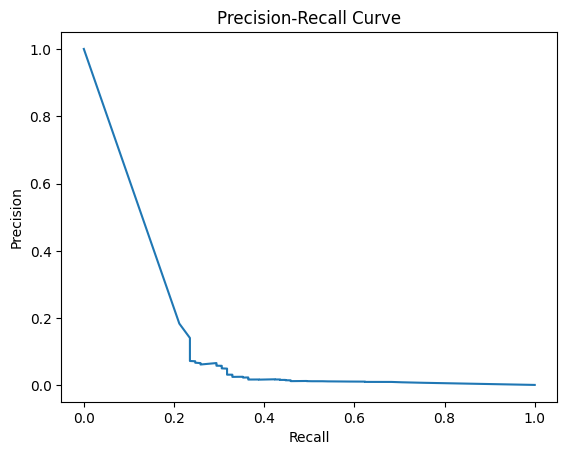

In [512]:
# 1. train SMOTE model
rf_model_sm.fit(X_train_sm, y_train_sm)

# 2. get probabilities
y_prob_sm = rf_model_sm.predict_proba(X_test)[:, 1]

# 3. draw PR curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob_sm)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [513]:
#In the final step, I used SMOTE to handle class imbalance and applied threshold tuning to
#improve fraud detection.

#I selected a threshold of 0.4 to balance precision and recall. Compared to the default threshold,
#the model was able to detect more fraud cases, but this also increased false positives.

#From the classification report and confusion matrix, we can see that the model improved in
#detecting fraud transactions, but it still makes mistakes by predicting some normal transactions as fraud.

#The ROC curve (AUC ≈ 0.83) shows that the model has a reasonable ability to distinguish between
##fraud and non-fraud cases.

#The Precision-Recall curve shows that precision decreases as recall increases,
#which is expected for imbalanced datasets. This means that detecting more fraud comes with more false alarms.

#Overall, the model improved after applying SMOTE and threshold tuning, but there is still a
#trade-off between detecting fraud and avoiding false positives.

In [514]:
#XG BOOST

In [515]:
!pip install xgboost

In [516]:
from xgboost import XGBClassifier

In [517]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [518]:
y_pred_xgb = xgb_model.predict(X_test)

In [519]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     63915
           1       0.02      0.81      0.04        85

    accuracy                           0.94     64000
   macro avg       0.51      0.88      0.50     64000
weighted avg       1.00      0.94      0.97     64000



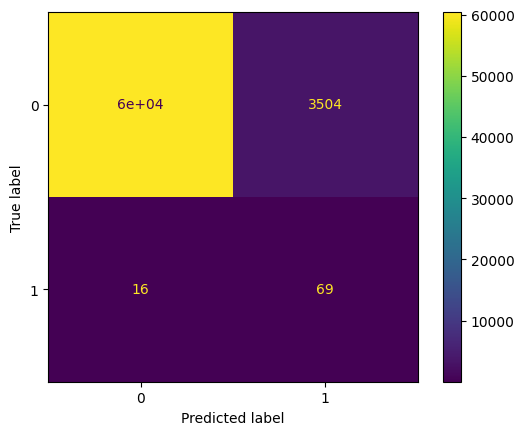

In [520]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

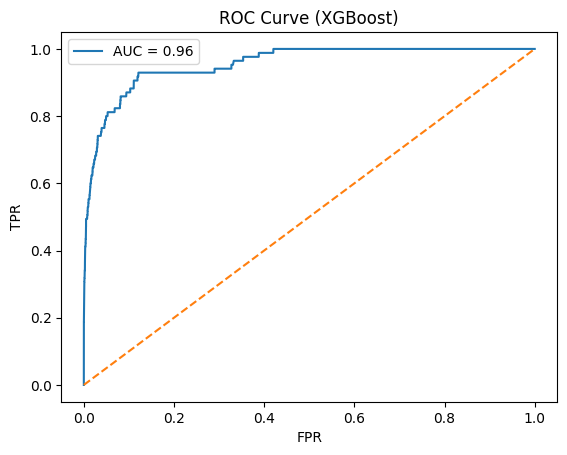

In [521]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (XGBoost)")
plt.legend()
plt.show()

In [522]:
#The confusion matrix shows that the XGBoost model detects most fraud cases (only 16 missed),
#indicating high recall.

#However, it produces a large number of false positives (3504),
#meaning many normal transactions are incorrectly flagged as fraud.

#This confirms that while the model is very effective at detecting fraud,
#it requires threshold tuning to reduce false alarms.

In [523]:
# find the best threshold

In [524]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred_temp = (y_prob_xgb > t).astype(int)

    print("Threshold:", t)
    print("Precision:", round(precision_score(y_test, y_pred_temp), 3))
    print("Recall:", round(recall_score(y_test, y_pred_temp), 3))
    print("F1:", round(f1_score(y_test, y_pred_temp), 3))
    print("-----")

Threshold: 0.3
Precision: 0.011
Recall: 0.882
F1: 0.022
-----
Threshold: 0.4
Precision: 0.014
Recall: 0.824
F1: 0.028
-----
Threshold: 0.5
Precision: 0.019
Recall: 0.812
F1: 0.038
-----
Threshold: 0.6
Precision: 0.024
Recall: 0.765
F1: 0.046
-----
Threshold: 0.7
Precision: 0.031
Recall: 0.718
F1: 0.059
-----


In [525]:
#final model setting

In [527]:
threshold = 0.7
y_pred_final = (y_prob_xgb > threshold).astype(int)

In [528]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     63915
           1       0.03      0.72      0.06        85

    accuracy                           0.97     64000
   macro avg       0.52      0.84      0.52     64000
weighted avg       1.00      0.97      0.98     64000



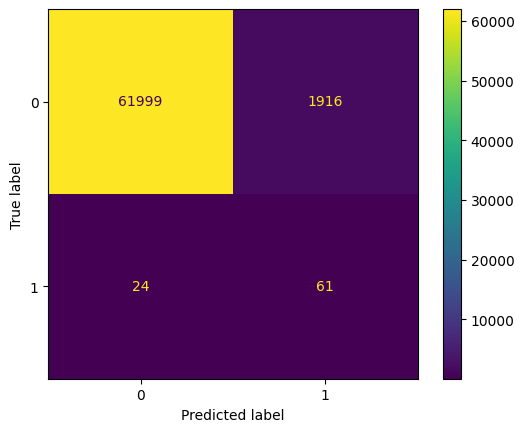

In [529]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
#After applying threshold tuning (0.7), the model achieved a recall of 0.72 for fraud detection,
#meaning it successfully identified most fraudulent transactions.

#However, the precision remains low (0.03), indicating a high number of false positives.
#This is expected in highly imbalanced datasets, where improving fraud detection often comes
#at the cost of more false alarms.

#Overall, the model prioritizes detecting fraud over avoiding false positives,
#which is often desirable in real-world fraud detection systems.

In [ ]:
#This trade-off can be adjusted depending on business requirements,
#where reducing false positives or increasing fraud detection may be prioritized.